In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad_vec, trapezoid, simpson
from scipy.special import roots_legendre

# Zadanie 1

Oblicz wartość całki z poprzedniego laboratorium:
$$ \int_{0}^{1} \frac{4}{1+x^2} \,dx = \pi \text{ ,} \tag{1} $$
korzystając z:

(a) kwadratur adaptacyjnych trapezów,

(b) kwadratur adaptacyjnych Gaussa-Kronroda.

In [2]:
def f_1(x):
    return 4 / (1 + x ** 2)

Dla każdej metody narysuj wykres wartości bezwzględnej błędu względnego w zależności od liczby ewaluacji funkcji podcałkowej. Wyniki dodaj do wykresu uzyskanego w poprzednim laboratorium. Przydatna będzie funkcja `scipy.integrate.quad_vec`. Na liczbę ewaluacji funkcji podcałkowej można wpływać pośrednio, zmieniając wartość dopuszczalnego błędu (tolerancji). Przyjmij wartości tolerancji z zakresu od $10^0$ do $10^{−14}$. Liczba ewaluacji funkcji podcałkowej zwracana jest w zmiennej `info[’neval’]`.

In [3]:
def quad_vec_trapezoid(f_x, a, b, eps, f_exact):
    res, err, info = quad_vec(
        f_x, a, b, epsrel=eps, quadrature="trapezoid", full_output=True
    )
    return res, np.abs((res - f_exact) / f_exact), info.neval

In [4]:
def quad_vec_gk21(f_x, a, b, eps, f_exact):
    res, err, info = quad_vec(
        f_x, a, b, epsrel=eps, quadrature="gk21", full_output=True
    )
    return res, np.abs((res - f_exact) / f_exact), info.neval

In [5]:
def midpoint_rule(y, x):
    """
    y: Input array to integrate.
    x: The sample points corresponding to the y values.
    """
    # result = .0
    # for i in range(len(y) - 1):
    #     result += (x[i + 1] - x[i]) * y[i]
    # return result
    return np.sum(y[:-1] * (x[1:] - x[:-1]))

In [6]:
def quad_midpoint(f_x, a, b, neval, f_exact):
    xs = np.linspace(a, b, neval)
    ys = f_x(xs)
    res = midpoint_rule(x=xs, y=ys)
    return res, np.abs((res - f_exact) / f_exact), neval

In [7]:
def quad_trapezoid(f_x, a, b, neval, f_exact):
    xs = np.linspace(a, b, neval)
    ys = f_x(xs)
    res = trapezoid(x=xs, y=ys)
    return res, np.abs((res - f_exact) / f_exact), neval

In [8]:
def quad_simpson(f_x, a, b, neval, f_exact):
    xs = np.linspace(a, b, neval)
    ys = f_x(xs)
    res = simpson(x=xs, y=ys)
    return res, np.abs((res - f_exact) / f_exact), neval

In [9]:
def quad_gauss_legendre(f_x, a, b, neval, f_exact):
    xs, ws = roots_legendre(neval)
    xs_scaled = 0.5 * (b - a) * xs + 0.5 * (b + a)
    res =  np.sum(ws * f_x(xs_scaled)) * (b - a) / 2
    return res, np.abs((res - f_exact) / f_exact), neval

In [10]:
def get_results(f, a, b, f_exact):
    quad_results = {
        # "quad_type": [(result, relative_error, evaluations), ...]
        "quad_vec_trapezoid": [],
        "quad_vec_gk21": [],
        "quad_midpoint": [],
        "quad_trapezoid": [],
        "quad_simpson": [],
        "quad_gauss_legendre": [],
    }

    epsilons = np.float_power(10, np.arange(0, -15, -1))
    for eps in epsilons:
        quad_results["quad_vec_trapezoid"].append(
            quad_vec_trapezoid(f, a, b, eps, f_exact)
        )
        quad_results["quad_vec_gk21"].append(quad_vec_gk21(f, a, b, eps, f_exact))

    nevals = 2 ** np.arange(1, 26) + 1
    for neval in nevals:
        quad_results["quad_midpoint"].append(quad_midpoint(f, a, b, neval, f_exact))
        quad_results["quad_trapezoid"].append(quad_trapezoid(f, a, b, neval, f_exact))
        quad_results["quad_simpson"].append(quad_simpson(f, a, b, neval, f_exact))

    nevals = 2 ** np.arange(1, 13) + 1
    for neval in nevals:
        quad_results["quad_gauss_legendre"].append(quad_gauss_legendre(f, a, b, neval, f_exact))

    return quad_results

In [11]:
quad_results = get_results(f_1, 0, 1, np.pi)

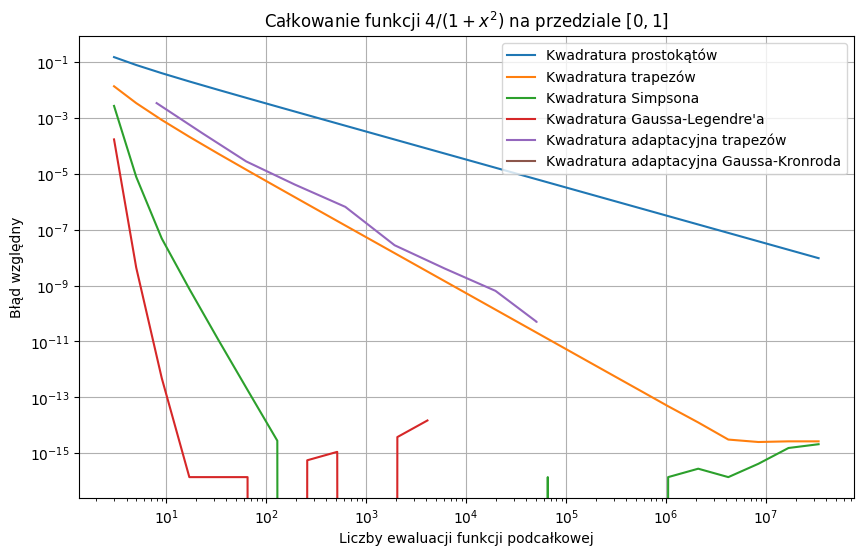

In [12]:
plt.figure(figsize=(10, 6))
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_midpoint"]],
    [rel_err for res, rel_err, neval in quad_results["quad_midpoint"]],
    label="Kwadratura prostokątów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_trapezoid"]],
    label="Kwadratura trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_simpson"]],
    [rel_err for res, rel_err, neval in quad_results["quad_simpson"]],
    label="Kwadratura Simpsona",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    [rel_err for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    label="Kwadratura Gaussa-Legendre'a",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    label="Kwadratura adaptacyjna trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    label="Kwadratura adaptacyjna Gaussa-Kronroda",
)

plt.xlabel("Liczby ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title("Całkowanie funkcji $4/(1 + x^2)$ na przedziale $[0, 1]$")
plt.grid(True)
plt.legend()
plt.show()

# Zadanie 2

Powtórz obliczenia z poprzedniego oraz dzisiejszego laboratorium dla całek

(a)
$$ \int_{0}^{1} \sqrt{x} \log{x} \,dx = - \frac{4}{9} \text{ ,} \tag{2}$$

(b)
$$ \int_{0}^{1} \left( \frac{1}{(x-0.3)^2 + a} + \frac{1}{(x - 0.9)^2 + b} - 6 \right) \,dx \text{ .} \tag{3}$$

We wzorze (3) przyjmij $a = 0.001$ oraz $b = 0.004$. Błąd kwadratury dla całki (3) oblicz, wykorzystuje fakt, że
$$ \int_{0}^{1} \frac{1}{(x-x_0)^2 + a} \,dx = \frac{1}{\sqrt{a}} \left( \arctg{\frac{1-x_0}{\sqrt{a}}} + \arctg{\frac{x_0}{\sqrt{a}}} \right) \text{ .} \tag{4}$$

In [13]:
def f_2(x):
    return np.sqrt(x) * np.log(x)


f_2_exact = -4 / 9
quad_results = get_results(f_2, np.finfo(float).eps, 1, f_2_exact)

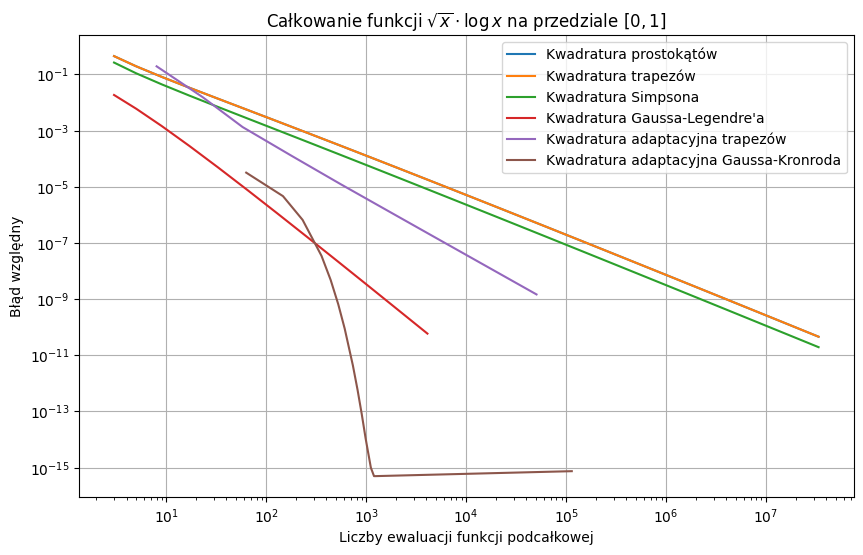

In [14]:
plt.figure(figsize=(10, 6))
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_midpoint"]],
    [rel_err for res, rel_err, neval in quad_results["quad_midpoint"]],
    label="Kwadratura prostokątów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_trapezoid"]],
    label="Kwadratura trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_simpson"]],
    [rel_err for res, rel_err, neval in quad_results["quad_simpson"]],
    label="Kwadratura Simpsona",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    [rel_err for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    label="Kwadratura Gaussa-Legendre'a",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    label="Kwadratura adaptacyjna trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    label="Kwadratura adaptacyjna Gaussa-Kronroda",
)

plt.xlabel("Liczby ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title(r"Całkowanie funkcji $\sqrt{x} \cdot \log{x}$ na przedziale $[0, 1]$")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
def f_3(x, a=0.001, b=0.004):
    return 1 / ((x - 0.3) ** 2 + a) + 1 / ((x - 0.9) ** 2 + b) - 6

def f_part_exact(x_0, a):
    return 1 / np.sqrt(a) * (np.arctan((1 - x_0) / np.sqrt(a)) + np.arctan(x_0 / np.sqrt(a)))

f_3_exact = f_part_exact(0.3, 0.001) + f_part_exact(0.9, 0.004) - 6
quad_results = get_results(f_3, 0, 1, f_3_exact)

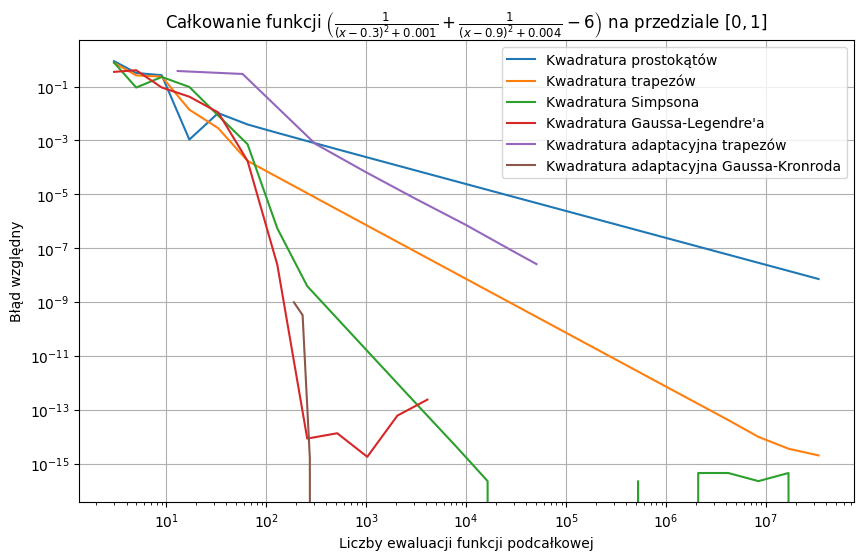

In [16]:
plt.figure(figsize=(10, 6))
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_midpoint"]],
    [rel_err for res, rel_err, neval in quad_results["quad_midpoint"]],
    label="Kwadratura prostokątów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_trapezoid"]],
    label="Kwadratura trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_simpson"]],
    [rel_err for res, rel_err, neval in quad_results["quad_simpson"]],
    label="Kwadratura Simpsona",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    [rel_err for res, rel_err, neval in quad_results["quad_gauss_legendre"]],
    label="Kwadratura Gaussa-Legendre'a",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_trapezoid"]],
    label="Kwadratura adaptacyjna trapezów",
)
plt.loglog(
    [neval for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    [rel_err for res, rel_err, neval in quad_results["quad_vec_gk21"]],
    label="Kwadratura adaptacyjna Gaussa-Kronroda",
)

plt.xlabel("Liczby ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title(
    r"Całkowanie funkcji $\left( \frac{1}{(x-0.3)^2 + 0.001} + \frac{1}{(x - 0.9)^2 +0.004} - 6 \right)$ na przedziale $[0, 1]$"
)
plt.grid(True)
plt.legend()
plt.show()